In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='Set2')
print('Libraries loaded successfully.')

Libraries loaded successfully.


Task 1 – Exploratory Data Analysis (EDA)

In [ ]:
 = pd.read_csv('')


In [27]:
raw_df = pd.read_csv("/content/drive/MyDrive/Lab_Exam_binary_classification_dataset.csv")
print('Raw shape:', raw_df.shape)
raw_df.head(10)

Raw shape: (1020, 3)


,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No
5,1.3375,532,No
6,2.0000,612,No
7,1.5000,612,No
8,1.7250,408,No
9,1.9625,632,No


In [12]:
print(df.head())
print(df.shape)

   Feature1  Feature2 Target
0    1.7250       520    Yes
1    1.8875       428     No
2    1.6000       552    Yes
3    1.4250       500     No
4    1.7750       628     No
(1020, 3)


Data Types

In [13]:
print(df.dtypes)

Feature1    float64
Feature2      int64
Target       object
dtype: object


Check Missing Values         

In [14]:
print(df.isnull().sum())

Feature1     0
Feature2     0
Target      20
dtype: int64


Handle Missing Values

In [15]:
df = df.dropna(subset=['Target'])


Rows with missing target values are removed.



In [16]:
print(df.describe())

           Feature1     Feature2
count   1000.000000  1000.000000
mean      11.632912   521.208000
std      316.176154    70.040148
min        1.250000   400.000000
25%        1.450000   464.000000
50%        1.637500   520.000000
75%        1.837500   584.000000
max    10000.000000   640.000000


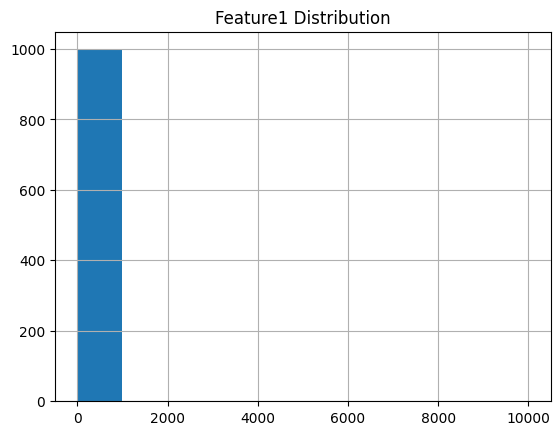

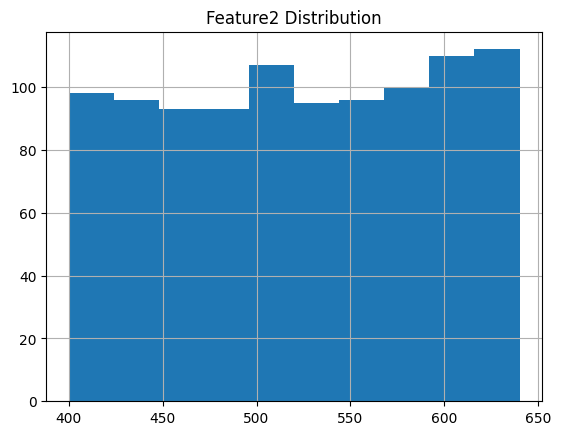

In [17]:
import matplotlib.pyplot as plt

df['Feature1'].hist()
plt.title("Feature1 Distribution")
plt.show()

df['Feature2'].hist()
plt.title("Feature2 Distribution")
plt.show()

Target Variable

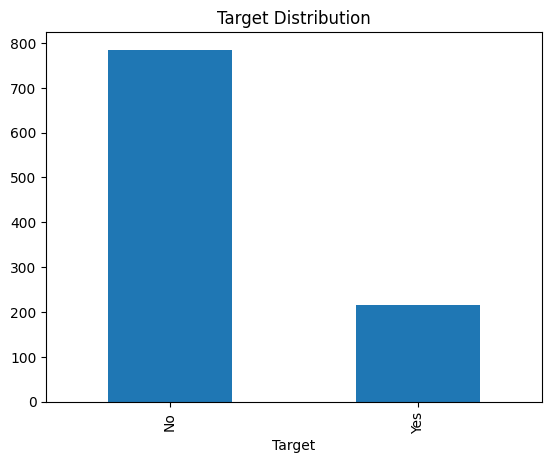

In [18]:
df['Target'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

Correlation Analysis

          Feature1  Feature2
Feature1  1.000000  0.044618
Feature2  0.044618  1.000000


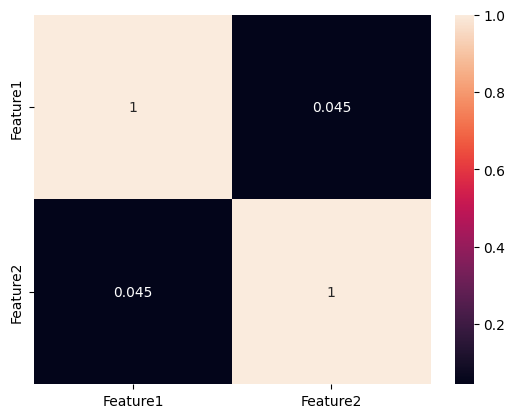

In [21]:
print(df.corr(numeric_only=True))

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

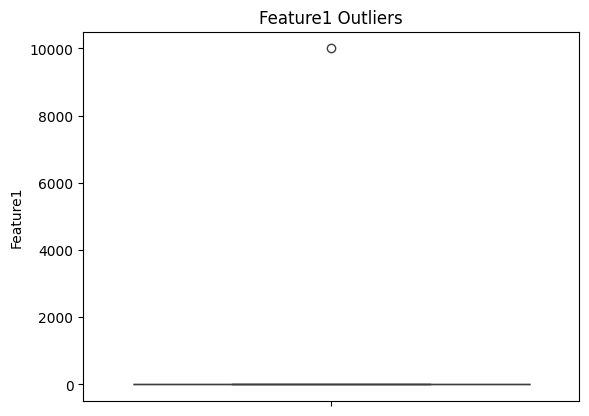

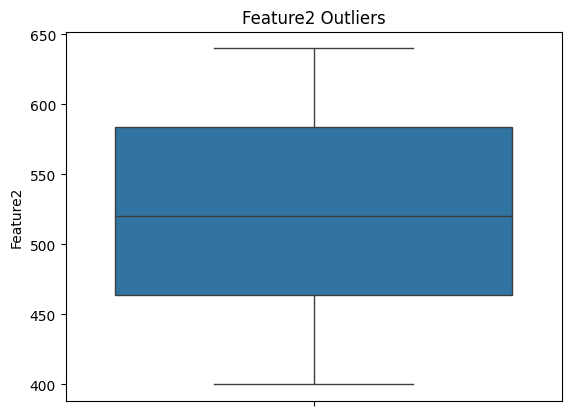

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df['Feature1'])
plt.title("Feature1 Outliers")
plt.show()

sns.boxplot(df['Feature2'])
plt.title("Feature2 Outliers")
plt.show()

Outlier Removal (IQR Method)

In [23]:
for col in ['Feature1', 'Feature2']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

Verify Outliers Removed

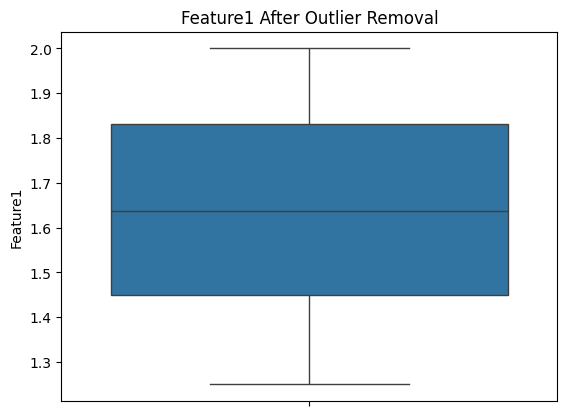

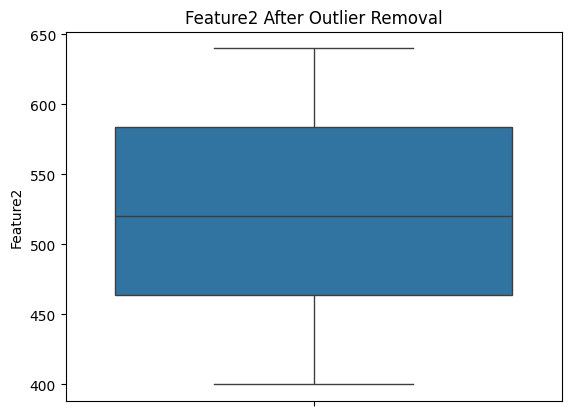

In [24]:
sns.boxplot(df['Feature1'])
plt.title("Feature1 After Outlier Removal")
plt.show()

sns.boxplot(df['Feature2'])
plt.title("Feature2 After Outlier Removal")
plt.show()